# Copa 2026 — EDA validada, concisa e reprodutível

Objetivo: refazer a EDA do notebook original sem depender de inferências frágeis. A base de elencos é validada contra a **Squad List oficial da FIFA**. A EDA de jogos só é executada quando há arquivo local com placares e o notebook evita double counting.

Fontes de validação usadas no notebook:

- FIFA Football Data Platform — `SquadLists-English.pdf`: fonte primária para jogadores, clubes, altura, caps e gols.
- FIFA — página de formato/grupos/tiebreakers da Copa 2026: fonte primária para o desenho do torneio.
- FIFA — página de calendário/resultados: referência para validação externa de partidas quando você tiver placares locais.

Princípio metodológico: **dado observado primeiro; hipótese depois; causalidade só com evidência adicional**.

In [1]:
from __future__ import annotations

import json
import math
import re
import shutil
import subprocess
import unicodedata
from datetime import date
from itertools import combinations
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 180)

FIFA_SQUAD_URL = "https://fdp.fifa.org/assetspublic/ce281/pdf/SquadLists-English.pdf"
FIFA_FORMAT_URL = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/groups-how-teams-qualify-tie-breakers"
FIFA_SCHEDULE_URL = "https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/articles/match-schedule-fixtures-results-teams-stadiums"
TOURNAMENT_START = pd.Timestamp("2026-06-11")

CWD = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    # Evita escolher "/" só porque algum ambiente temporário criou /data/gold.
    # Em projeto local, escolha o primeiro pai que já tenha data/gold ou data/raw.
    for p in [start, *start.parents]:
        if p == Path(p.anchor):
            continue
        if (p / "data" / "gold").exists() or (p / "data" / "raw").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(CWD)
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
GOLD_DIR = DATA_DIR / "gold"
OUT_DIR = GOLD_DIR / "eda_validada_outputs"

# No ChatGPT/sandbox, os arquivos ficam em /mnt/data; em projeto local, ficam em data/raw e data/gold.
SANDBOX_DIR = Path("/mnt/data")
for d in [RAW_DIR, GOLD_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("CWD          =", CWD)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("RAW_DIR      =", RAW_DIR)
print("GOLD_DIR     =", GOLD_DIR)
print("OUT_DIR      =", OUT_DIR)

CWD          = /home/perri/Área de trabalho/copa/copa_local_etl_scripts
PROJECT_ROOT = /home/perri/Área de trabalho/copa/copa_local_etl_scripts
RAW_DIR      = /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/raw
GOLD_DIR     = /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold
OUT_DIR      = /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs


In [2]:
def clean_text(x) -> str:
    if pd.isna(x):
        return ""
    return re.sub(r"\s+", " ", str(x).replace(" ", " ")).strip()


def norm_key(x) -> str:
    s = unicodedata.normalize("NFKD", clean_text(x)).encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return re.sub(r"_+", "_", s).strip("_")


def find_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def first_existing(paths: list[Path]) -> Path | None:
    for p in paths:
        if p.exists():
            return p
    return None


def save_df(df: pd.DataFrame, name: str, index: bool = False) -> Path:
    path = OUT_DIR / name
    df.to_csv(path, index=index)
    print("salvo:", path)
    return path


def quick_bar(df: pd.DataFrame, value: str, label: str, title: str, n: int = 20):
    if df.empty or value not in df or label not in df:
        print("sem dados para", title)
        return
    d = df[[label, value]].dropna().head(n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.32 * len(d))))
    ax.barh(d[label].astype(str), d[value])
    ax.set_title(title)
    ax.set_xlabel(value)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 1. Registro das fontes e nível de confiança

A EDA usa a FIFA como fonte primária para elenco e formato. Wikipedia/X/Grok não entram como fonte primária neste notebook.

In [3]:
source_manifest = pd.DataFrame([
    {
        "source_name": "FIFA Squad List PDF",
        "url": FIFA_SQUAD_URL,
        "type": "primary",
        "used_for": "jogadores, seleção, clube, altura, caps, gols",
        "validation_rule": "1248 jogadores = 48 seleções × 26; 26 por seleção; colunas numéricas em faixa plausível",
    },
    {
        "source_name": "FIFA Groups / qualification / tiebreakers",
        "url": FIFA_FORMAT_URL,
        "type": "primary",
        "used_for": "formato do torneio: 12 grupos de 4; top 2 + 8 melhores terceiros",
        "validation_rule": "usado como referência de escopo; não é usado para placares",
    },
    {
        "source_name": "FIFA Schedule / results",
        "url": FIFA_SCHEDULE_URL,
        "type": "primary",
        "used_for": "referência para auditoria de placares quando houver base local de jogos",
        "validation_rule": "placares locais devem ser reconciliados com fonte oficial ou provedor confiável",
    },
])
display(source_manifest)
save_df(source_manifest, "source_manifest.csv")

,source_name,url,type,used_for,validation_rule
0,FIFA Squad List PDF,https://fdp.fifa.org/assetspublic/ce281/pdf/Sq...,primary,"jogadores, seleção, clube, altura, caps, gols",1248 jogadores = 48 seleções × 26; 26 por sele...
1,FIFA Groups / qualification / tiebreakers,https://www.fifa.com/en/tournaments/mens/world...,primary,formato do torneio: 12 grupos de 4; top 2 + 8 ...,usado como referência de escopo; não é usado p...
2,FIFA Schedule / results,https://www.fifa.com/en/tournaments/mens/world...,primary,referência para auditoria de placares quando h...,placares locais devem ser reconciliados com fo...


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/source_manifest.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/source_manifest.csv')

## 2. Elenco oficial da FIFA: download, parsing e validação forte

Esta seção corrige o principal problema do notebook original: **não confiar em caps/gols extraídos por parser frágil**. O PDF oficial tem colunas explícitas `HEIGHT (CM)`, `CAPS` e `GOALS`; o notebook valida contagens e faixas antes de usar qualquer métrica.

In [4]:
def ensure_official_pdf() -> Path:
    candidates = [
        RAW_DIR / "SquadLists-English.pdf",
        SANDBOX_DIR / "SquadLists-English.pdf",
        CWD / "SquadLists-English.pdf",
    ]
    existing = first_existing(candidates)
    if existing:
        target = RAW_DIR / "SquadLists-English.pdf"
        if existing.resolve() != target.resolve():
            shutil.copy2(existing, target)
        return target

    target = RAW_DIR / "SquadLists-English.pdf"
    print("baixando PDF oficial da FIFA...")
    urlretrieve(FIFA_SQUAD_URL, target)
    return target


def pdf_to_text_layout(pdf_path: Path) -> str:
    # Preferência: pdftotext -layout, porque preserva as colunas melhor que extração simples.
    if shutil.which("pdftotext"):
        txt_path = pdf_path.with_suffix(".txt")
        subprocess.run(["pdftotext", "-layout", str(pdf_path), str(txt_path)], check=True)
        return txt_path.read_text(encoding="utf-8", errors="ignore")

    try:
        import pdfplumber
    except Exception as e:
        raise RuntimeError(
            "Não encontrei 'pdftotext' nem 'pdfplumber'. Instale um deles ou forneça fifa_2026_squad_official_parsed.csv."
        ) from e

    pages = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            pages.append(page.extract_text(x_tolerance=1, y_tolerance=3) or "")
    return "\n".join(pages)


def parse_fifa_squad_text(text: str) -> pd.DataFrame:
    team_re = re.compile(r"^\s{20,}(.+?) \(([A-Z]{3})\)\s*$")
    row_re = re.compile(
        r"^\s*(\d{1,2})\s+(GK|DF|MF|FW)\s+(.+?)\s+"
        r"(\d{2}/\d{2}/\d{4})\s+(.+?)\s+(\d{3})\s+(\d+)\s+(\d+)\s*$"
    )

    rows = []
    team_name, team_code = None, None

    for line in text.splitlines():
        mt = team_re.match(line)
        if mt and "FIFA World Cup" not in mt.group(1) and "SQUAD LIST" not in mt.group(1):
            team_name, team_code = mt.group(1).strip(), mt.group(2).strip()

        mr = row_re.match(line)
        if mr and team_name:
            num, pos, rest, dob, club, height, caps, goals = mr.groups()
            parts = re.split(r"\s{2,}", rest.strip())
            rows.append({
                "team": team_name,
                "team_code": team_code,
                "shirt_number": int(num),
                "position": pos,
                "player_name": parts[0] if len(parts) > 0 else "",
                "first_names": parts[1] if len(parts) > 1 else "",
                "last_names": parts[2] if len(parts) > 2 else "",
                "name_on_shirt": parts[3] if len(parts) > 3 else "",
                "dob": dob,
                "club": club.strip(),
                "height_cm": int(height),
                "caps": int(caps),
                "goals": int(goals),
                "source": "FIFA SquadLists-English.pdf",
            })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("Parser não encontrou jogadores no PDF oficial.")
    return df


def load_official_roster() -> pd.DataFrame:
    parsed_candidates = [
        RAW_DIR / "fifa_2026_squad_official_parsed.csv",
        SANDBOX_DIR / "fifa_2026_squad_official_parsed.csv",
        CWD / "fifa_2026_squad_official_parsed.csv",
    ]
    parsed = first_existing(parsed_candidates)
    if parsed:
        print("usando CSV oficial já parseado:", parsed)
        return pd.read_csv(parsed)

    pdf_path = ensure_official_pdf()
    text = pdf_to_text_layout(pdf_path)
    df = parse_fifa_squad_text(text)
    df.to_csv(RAW_DIR / "fifa_2026_squad_official_parsed.csv", index=False)
    return df

official = load_official_roster()
official["dob_dt"] = pd.to_datetime(official["dob"], format="%d/%m/%Y", errors="coerce")
official["age_at_start"] = ((TOURNAMENT_START - official["dob_dt"]).dt.days / 365.25).round(2)
official["club_country_code"] = official["club"].str.extract(r"\(([A-Z]{3})\)\s*$")
official["player_key"] = official["player_name"].map(norm_key)
official["team_key"] = official["team"].map(norm_key)

display(official.head())
print("linhas:", len(official), "seleções:", official["team_code"].nunique())

usando CSV oficial já parseado: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/raw/fifa_2026_squad_official_parsed.csv


,team,team_code,shirt_number,position,player_name,first_names,last_names,name_on_shirt,dob,club,height_cm,caps,goals,source,dob_dt,age_at_start,club_country_code,player_key,team_key
0,Algeria,ALG,1,GK,MASTIL Melvin,Melvin Feycal,MASTIL,MASTIL,19/02/2000,FC Stade Nyonnais (SUI),194,2,0,FIFA SquadLists-English.pdf,2000-02-19,26.31,SUI,mastil_melvin,algeria
1,Algeria,ALG,2,DF,MANDI Aissa,Aissa,MANDI,MANDI,22/10/1991,Lille OSC (FRA),184,121,8,FIFA SquadLists-English.pdf,1991-10-22,34.64,FRA,mandi_aissa,algeria
2,Algeria,ALG,3,DF,ABADA Achref,Achref,ABADA,ABADA,15/06/1999,USM Alger (ALG),185,10,1,FIFA SquadLists-English.pdf,1999-06-15,26.99,ALG,abada_achref,algeria
3,Algeria,ALG,4,DF,TOUGAI Mohamed Amine,Mohamed Amine,TOUGAI,TOUGAI,22/01/2000,Espérance De Tunisie (TUN),186,30,2,FIFA SquadLists-English.pdf,2000-01-22,26.38,TUN,tougai_mohamed_amine,algeria
4,Algeria,ALG,5,DF,BELAID Zineddine,Zineddine,BELAÏD,BELAID,20/03/1999,JS Kabylie (ALG),186,19,1,FIFA SquadLists-English.pdf,1999-03-20,27.23,ALG,belaid_zineddine,algeria


linhas: 1248 seleções: 48


In [5]:
validation = []

def check(name: str, passed: bool, observed, expected=None, severity="error"):
    validation.append({
        "check": name,
        "passed": bool(passed),
        "observed": observed,
        "expected": expected,
        "severity": severity,
    })

check("total de jogadores", len(official) == 1248, len(official), "1248 = 48 × 26")
check("total de seleções", official["team_code"].nunique() == 48, official["team_code"].nunique(), 48)
team_counts = official.groupby("team_code").size()
check("26 jogadores por seleção", bool((team_counts == 26).all()), team_counts[team_counts != 26].to_dict(), "todas com 26")
check("sem duplicata team_code + shirt_number", not official.duplicated(["team_code", "shirt_number"]).any(), int(official.duplicated(["team_code", "shirt_number"]).sum()), 0)
check("posições válidas", set(official["position"]).issubset({"GK", "DF", "MF", "FW"}), sorted(official["position"].unique()), "GK/DF/MF/FW")
check("altura plausível", official["height_cm"].between(150, 220).all(), official.loc[~official["height_cm"].between(150, 220), ["team", "player_name", "height_cm"]].to_dict("records"), "150-220")
check("caps plausível", official["caps"].between(0, 250).all(), official.loc[~official["caps"].between(0, 250), ["team", "player_name", "caps"]].to_dict("records"), "0-250")
check("gols plausível", official["goals"].between(0, 150).all(), official.loc[~official["goals"].between(0, 150), ["team", "player_name", "goals"]].to_dict("records"), "0-150")
check("DOB parseável", official["dob_dt"].notna().all(), int(official["dob_dt"].isna().sum()), 0)

validation_df = pd.DataFrame(validation)
display(validation_df)
save_df(validation_df, "official_roster_validation.csv")

if validation_df.query("severity == 'error' and passed == False").shape[0] > 0:
    raise AssertionError("Falha em validação crítica do elenco oficial. Veja official_roster_validation.csv")
else:
    print("Validação crítica aprovada.")

,check,passed,observed,expected,severity
0,total de jogadores,True,1248,1248 = 48 × 26,error
1,total de seleções,True,48,48,error
2,26 jogadores por seleção,True,{},todas com 26,error
3,sem duplicata team_code + shirt_number,True,0,0,error
4,posições válidas,True,"[DF, FW, GK, MF]",GK/DF/MF/FW,error
5,altura plausível,True,[],150-220,error
6,caps plausível,True,[],0-250,error
7,gols plausível,True,[],0-150,error
8,DOB parseável,True,0,0,error


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/official_roster_validation.csv
Validação crítica aprovada.


## 3. Conciliação com os CSVs locais do projeto

A fonte oficial da FIFA vence conflitos em `height_cm`, `caps` e `goals`. Os CSVs locais entram apenas para enriquecer com features já calculadas, nunca para sobrescrever o dado oficial sem auditoria.

In [6]:
local_player_candidates = [
    GOLD_DIR / "gold_worldcup_players_2026_fifa_official.csv",
    GOLD_DIR / "worldcup_2026_player_profile_features.csv",
    CWD / "gold_worldcup_players_2026_fifa_official.csv",
    CWD / "worldcup_2026_player_profile_features.csv",
]
local_path = first_existing(local_player_candidates)
players_local = pd.read_csv(local_path) if local_path else pd.DataFrame()
print("CSV local:", local_path if local_path else "não encontrado; usando somente FIFA oficial")

players = official.copy()
reconciliation = pd.DataFrame()

if not players_local.empty:
    name_col = find_col(players_local, ["player_name", "name", "fifa_player_name", "nome"])
    team_col = find_col(players_local, ["team_code", "country_code", "country_en", "team_name", "fifa_team_name", "selection"])
    shirt_col = find_col(players_local, ["shirt_number", "number", "squad_number", "#"])
    height_col = find_col(players_local, ["height_cm", "height", "HEIGHT (CM)"])
    caps_col = find_col(players_local, ["caps", "caps_fifa", "international_caps"])
    goals_col = find_col(players_local, ["goals", "international_goals", "goals_fifa"])

    local = players_local.copy()
    local["local_player_key"] = local[name_col].map(norm_key) if name_col else ""

    if team_col and team_col in local:
        if local[team_col].astype(str).str.fullmatch(r"[A-Z]{3}").fillna(False).mean() > 0.8:
            local["local_team_code"] = local[team_col].astype(str).str.upper()
        else:
            team_name_to_code = official.drop_duplicates("team_key").set_index("team_key")["team_code"].to_dict()
            local["local_team_code"] = local[team_col].map(lambda x: team_name_to_code.get(norm_key(x), ""))
    else:
        local["local_team_code"] = ""

    if shirt_col:
        local["local_shirt_number"] = pd.to_numeric(local[shirt_col], errors="coerce").astype("Int64")
    else:
        local["local_shirt_number"] = pd.NA

    if shirt_col and local["local_shirt_number"].notna().any():
        merged = official.merge(
            local,
            left_on=["team_code", "shirt_number"],
            right_on=["local_team_code", "local_shirt_number"],
            how="left",
            suffixes=("_fifa", "_local"),
        )
        match_method = "team_code + shirt_number"
    else:
        merged = official.merge(
            local,
            left_on=["team_code", "player_key"],
            right_on=["local_team_code", "local_player_key"],
            how="left",
            suffixes=("_fifa", "_local"),
        )
        match_method = "team_code + player_name normalizado"

    checks = []
    for src_col, official_col in [(height_col, "height_cm"), (caps_col, "caps"), (goals_col, "goals")]:
        if src_col and src_col in merged:
            local_num = pd.to_numeric(merged[src_col], errors="coerce")
            diff = merged[local_num.notna() & (local_num != merged[official_col])]
            for _, r in diff[["team", "player_name", official_col, src_col]].head(200).iterrows():
                checks.append({
                    "match_method": match_method,
                    "team": r["team"],
                    "player_name": r["player_name"],
                    "field": official_col,
                    "fifa_value": r[official_col],
                    "local_value": r[src_col],
                })

    reconciliation = pd.DataFrame(checks)
    print("Método de conciliação:", match_method)
    print("linhas com divergência em height/caps/goals:", len(reconciliation))
    display(reconciliation.head(30))
    save_df(reconciliation, "local_vs_fifa_reconciliation_issues.csv")

# A base analítica sempre parte da FIFA oficial.
players = official.copy()
print("Base analítica de jogadores:", players.shape)

CSV local: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/gold_worldcup_players_2026_fifa_official.csv
Método de conciliação: team_code + shirt_number
linhas com divergência em height/caps/goals: 0


""


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/local_vs_fifa_reconciliation_issues.csv
Base analítica de jogadores: (1248, 19)


## 4. EDA dos elencos oficiais

Estas métricas são seguras porque vêm do PDF oficial validado. A idade é calculada na data de abertura do torneio.

In [7]:
team_summary = (
    players.groupby(["team", "team_code"], as_index=False)
    .agg(
        players=("player_name", "count"),
        avg_age=("age_at_start", "mean"),
        median_age=("age_at_start", "median"),
        avg_height_cm=("height_cm", "mean"),
        total_caps=("caps", "sum"),
        avg_caps=("caps", "mean"),
        median_caps=("caps", "median"),
        total_goals=("goals", "sum"),
        avg_goals=("goals", "mean"),
        clubs=("club", "nunique"),
        club_countries=("club_country_code", "nunique"),
    )
)

for col in ["avg_age", "median_age", "avg_height_cm", "avg_caps", "median_caps", "avg_goals"]:
    team_summary[col] = team_summary[col].round(2)

position_summary = (
    players.pivot_table(index=["team", "team_code"], columns="position", values="player_name", aggfunc="count", fill_value=0)
    .reset_index()
)

team_summary = team_summary.merge(position_summary, on=["team", "team_code"], how="left")

display(team_summary.sort_values("avg_caps", ascending=False).head(15))
display(team_summary.sort_values("total_goals", ascending=False).head(15))

save_df(players, "players_official_validated.csv")
save_df(team_summary, "team_roster_summary_official.csv")

,team,team_code,players,avg_age,median_age,avg_height_cm,total_caps,avg_caps,median_caps,total_goals,avg_goals,clubs,club_countries,DF,FW,GK,MF
35,Qatar,QAT,26,29.51,29.60,179.38,1618,62.23,51.5,217,8.35,8,2,9,9,3,5
32,Panama,PAN,26,30.43,29.85,181.58,1571,60.42,55.5,127,4.88,23,17,11,4,3,8
1,Argentina,ARG,26,29.12,28.28,179.58,1283,49.35,46.0,228,8.77,19,9,8,7,3,8
27,Mexico,MEX,26,27.90,28.52,179.50,1269,48.81,41.5,123,4.73,21,11,7,8,3,8
22,IR Iran,IRN,26,30.33,31.32,183.65,1221,46.96,35.5,151,5.81,14,5,9,6,3,8
11,Croatia,CRO,26,28.33,28.26,184.77,1192,45.85,21.5,156,6.00,24,8,8,6,3,9
34,Portugal,POR,26,28.04,26.86,181.50,1192,45.85,35.0,264,10.15,17,7,9,8,3,6
42,Switzerland,SUI,26,28.31,28.92,185.23,1180,45.38,30.0,131,5.04,24,6,8,7,3,8
4,Belgium,BEL,26,27.62,25.76,185.81,1133,43.58,31.0,219,8.42,18,8,9,6,3,8
25,Jordan,JOR,26,28.46,28.87,180.31,1095,42.12,36.5,92,3.54,14,9,9,6,3,8


,team,team_code,players,avg_age,median_age,avg_height_cm,total_caps,avg_caps,median_caps,total_goals,avg_goals,clubs,club_countries,DF,FW,GK,MF
34,Portugal,POR,26,28.04,26.86,181.50,1192,45.85,35.0,264,10.15,17,7,9,8,3,6
1,Argentina,ARG,26,29.12,28.28,179.58,1283,49.35,46.0,228,8.77,19,9,8,7,3,8
4,Belgium,BEL,26,27.62,25.76,185.81,1133,43.58,31.0,219,8.42,18,8,9,6,3,8
35,Qatar,QAT,26,29.51,29.60,179.38,1618,62.23,51.5,217,8.35,8,2,9,9,3,5
29,Netherlands,NED,26,27.77,27.10,185.15,909,34.96,26.5,162,6.23,19,8,8,7,3,8
6,Brazil,BRA,26,29.36,29.01,183.12,964,37.08,25.5,159,6.12,20,8,8,9,3,6
11,Croatia,CRO,26,28.33,28.26,184.77,1192,45.85,21.5,156,6.00,24,8,8,6,3,9
17,England,ENG,26,27.27,26.72,184.62,869,33.42,19.5,153,5.88,16,4,9,7,3,7
3,Austria,AUT,26,28.61,28.82,184.96,1036,39.85,33.0,151,5.81,22,10,8,4,3,11
22,IR Iran,IRN,26,30.33,31.32,183.65,1221,46.96,35.5,151,5.81,14,5,9,6,3,8


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/players_official_validated.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_roster_summary_official.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_roster_summary_official.csv')

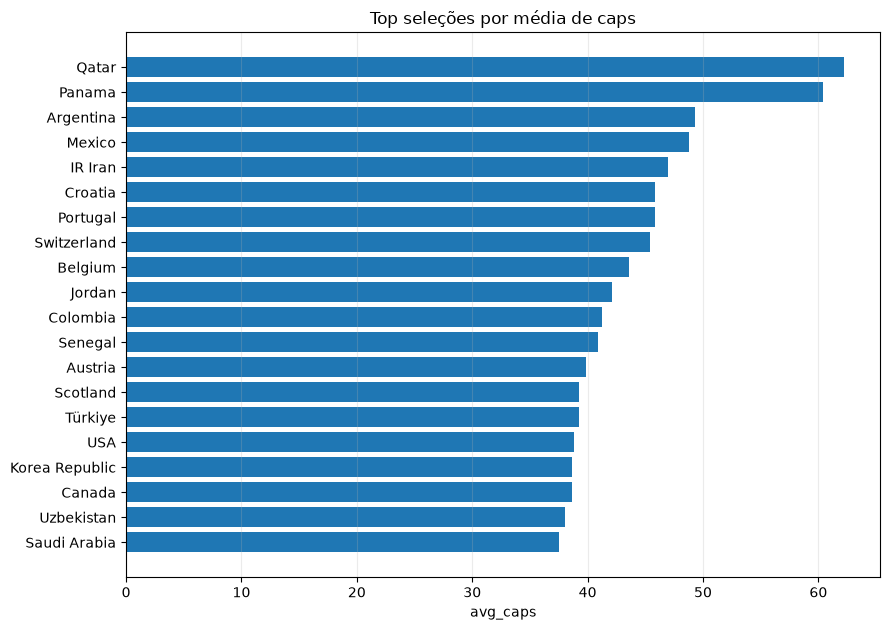

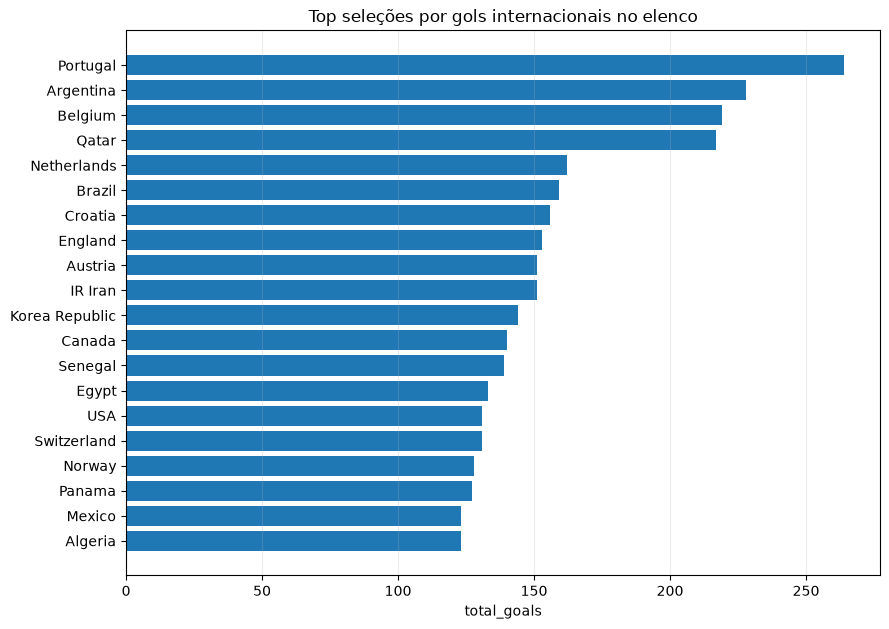

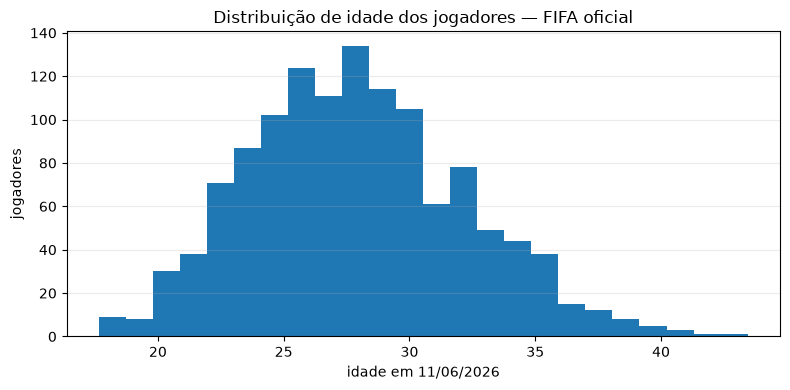

In [8]:
quick_bar(team_summary.sort_values("avg_caps", ascending=False), "avg_caps", "team", "Top seleções por média de caps", 20)
quick_bar(team_summary.sort_values("total_goals", ascending=False), "total_goals", "team", "Top seleções por gols internacionais no elenco", 20)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(players["age_at_start"].dropna(), bins=24)
ax.set_title("Distribuição de idade dos jogadores — FIFA oficial")
ax.set_xlabel("idade em 11/06/2026")
ax.set_ylabel("jogadores")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 5. Clubes e países dos clubes

Aqui usamos `club_country_code` extraído do sufixo do clube no PDF, por exemplo `(ENG)`. Isso **não é liga**. A análise por liga só deve existir quando houver uma tabela `club -> league` auditável.

,club,players,teams,team_list
279,Manchester City FC (ENG),19,12,Algeria | Belgium | Croatia | Egypt | England ...
162,FC Bayern München (GER),17,10,Austria | Canada | Colombia | Croatia | Englan...
320,Paris Saint-Germain (FRA),16,9,Brazil | Ecuador | France | Korea Republic | M...
65,Arsenal FC (ENG),15,9,Belgium | Brazil | Ecuador | England | France ...
161,FC Barcelona (ESP),15,8,Brazil | Egypt | England | France | Netherland...
142,Crystal Palace FC (ENG),12,10,Colombia | Côte D'Ivoire | England | France | ...
280,Manchester United FC (ENG),12,10,Argentina | Belgium | Brazil | Côte D'Ivoire |...
36,Al Hilal SC (KSA),12,6,France | Morocco | Portugal | Saudi Arabia | S...
72,Atlético De Madrid (ESP),12,5,Argentina | Mexico | Norway | Spain | Uruguay
86,Borussia Dortmund (GER),11,7,Algeria | Austria | Germany | Norway | Sweden ...


,club_country_code,players,clubs,teams
21,ENG,199,40,43
25,GER,110,22,30
22,ESP,85,22,31
24,FRA,84,22,28
36,ITA,71,21,29
41,KSA,50,13,19
64,TUR,45,13,20
67,USA,44,23,17
45,NED,38,16,17
8,BRA,32,13,7


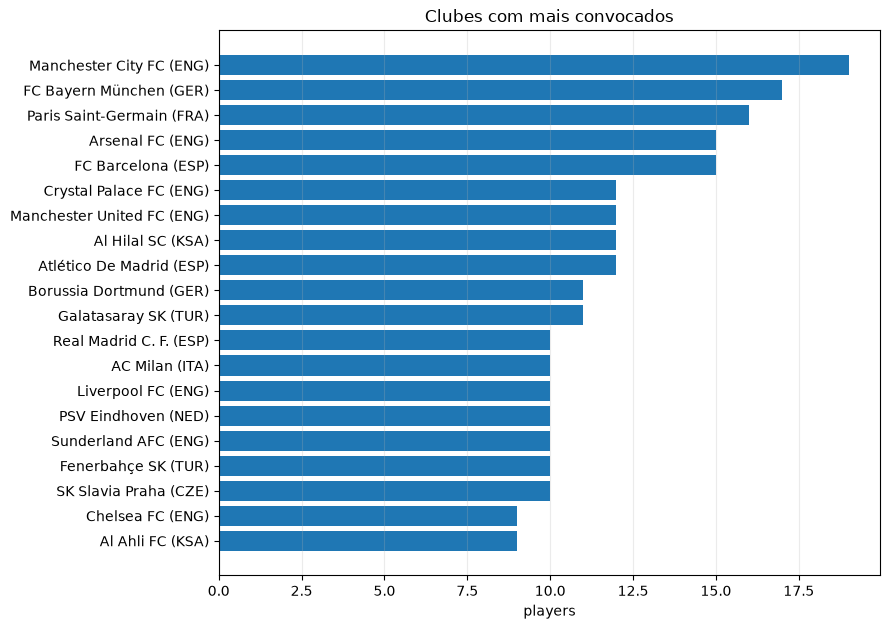

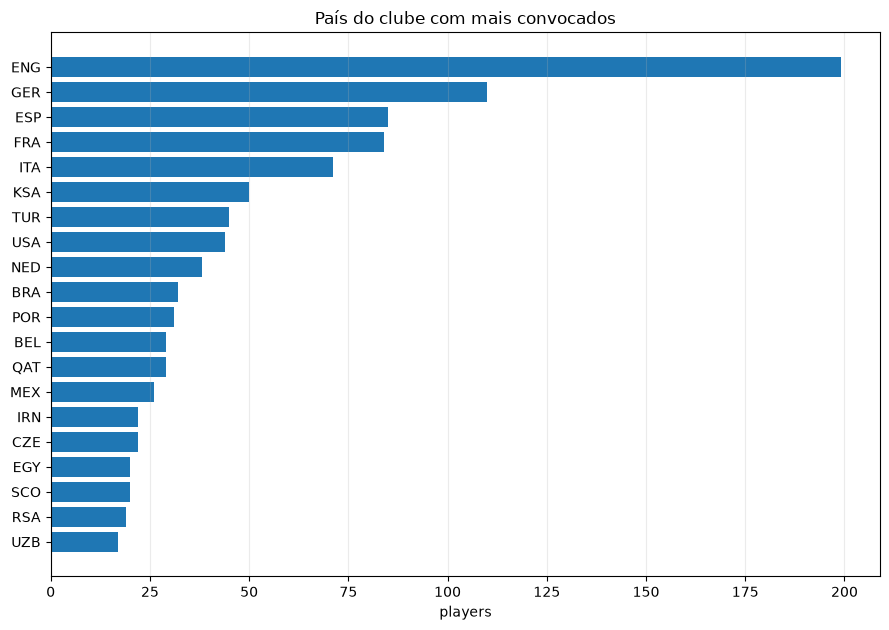

salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/club_summary_official.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/club_country_summary_official.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/club_country_summary_official.csv')

In [9]:
club_summary = (
    players.groupby("club", as_index=False)
    .agg(
        players=("player_name", "count"),
        teams=("team", "nunique"),
        team_list=("team", lambda s: " | ".join(sorted(s.unique()))),
    )
    .sort_values(["players", "teams"], ascending=[False, False])
)

club_country_summary = (
    players.groupby("club_country_code", as_index=False)
    .agg(players=("player_name", "count"), clubs=("club", "nunique"), teams=("team", "nunique"))
    .sort_values("players", ascending=False)
)

display(club_summary.head(25))
display(club_country_summary.head(25))
quick_bar(club_summary.head(20), "players", "club", "Clubes com mais convocados", 20)
quick_bar(club_country_summary.head(20), "players", "club_country_code", "País do clube com mais convocados", 20)

save_df(club_summary, "club_summary_official.csv")
save_df(club_country_summary, "club_country_summary_official.csv")

## 6. Partidas e gols — somente com escopo e double counting controlados

Esta seção é opcional. Ela usa arquivos locais se existirem, mas não inventa placares nem confunde `team-match` com `fixture`. Para média global de gols, use **fixtures únicas**, não linhas duplicadas por seleção.

In [10]:
match_candidates = [
    GOLD_DIR / "team_matches_2022_2026_free_sources.csv",
    GOLD_DIR / "team_matches_2022_2026_unique_fixtures.csv",
    GOLD_DIR / "wc2026_group_stage_matches.csv",
    CWD / "team_matches_2022_2026_free_sources.csv",
    CWD / "team_matches_2022_2026_unique_fixtures.csv",
    CWD / "wc2026_group_stage_matches.csv",
]
match_path = first_existing(match_candidates)
print("Arquivo de partidas:", match_path if match_path else "não encontrado")

matches_raw = pd.read_csv(match_path) if match_path else pd.DataFrame()
wc_team_names = set(players["team"].map(norm_key))
team_key_to_name = players.drop_duplicates("team_key").set_index("team_key")["team"].to_dict()

if matches_raw.empty:
    print("Sem base local de partidas. A EDA de jogos foi pulada.")
else:
    display(matches_raw.head())
    date_col = find_col(matches_raw, ["date", "match_date", "utc_date"])
    team_col = find_col(matches_raw, ["team", "team_name", "home_team", "home", "home_team_name"])
    opp_col = find_col(matches_raw, ["opponent", "away_team", "away", "away_team_name"])
    gf_col = find_col(matches_raw, ["goals_for", "home_goals", "gf", "team_goals"])
    ga_col = find_col(matches_raw, ["goals_against", "away_goals", "ga", "opponent_goals"])
    source_col = find_col(matches_raw, ["source", "source_url", "url", "provider"])

    required = {"team_col": team_col, "opp_col": opp_col, "gf_col": gf_col, "ga_col": ga_col}
    print("colunas detectadas:", required)
    if any(v is None for v in required.values()):
        raise ValueError("Não consegui detectar colunas mínimas de partidas. Padronize team/opponent/goals_for/goals_against ou home/away/home_goals/away_goals.")

    m = matches_raw.copy()
    m["team_key"] = m[team_col].map(norm_key)
    m["opponent_key"] = m[opp_col].map(norm_key)
    m["goals_for"] = pd.to_numeric(m[gf_col], errors="coerce")
    m["goals_against"] = pd.to_numeric(m[ga_col], errors="coerce")
    m["date_dt"] = pd.to_datetime(m[date_col], errors="coerce") if date_col else pd.NaT
    m["is_wc_team"] = m["team_key"].isin(wc_team_names)
    m["opponent_is_wc_team"] = m["opponent_key"].isin(wc_team_names)
    m["total_goals"] = m["goals_for"] + m["goals_against"]
    m["result"] = np.select(
        [m["goals_for"] > m["goals_against"], m["goals_for"] == m["goals_against"]],
        ["W", "D"],
        default="L",
    )

    team_matches = m[m["is_wc_team"]].copy()
    team_matches["team"] = team_matches["team_key"].map(team_key_to_name).fillna(team_matches[team_col])

    # Identificador de fixture: data + par ordenado de times + placar ordenado pela perspectiva da linha.
    a = team_matches[["team_key", "opponent_key"]].min(axis=1)
    b = team_matches[["team_key", "opponent_key"]].max(axis=1)
    team_matches["fixture_key"] = (
        team_matches["date_dt"].astype(str).fillna("") + "::" + a + "::" + b + "::" +
        team_matches[["goals_for", "goals_against"]].max(axis=1).astype(str) + "-" +
        team_matches[["goals_for", "goals_against"]].min(axis=1).astype(str)
    )
    unique_fixtures = team_matches.drop_duplicates("fixture_key").copy()

    match_quality = pd.DataFrame([
        {"check": "linhas de seleções da Copa", "value": len(team_matches)},
        {"check": "fixtures únicos", "value": len(unique_fixtures)},
        {"check": "placares ausentes", "value": int(team_matches[["goals_for", "goals_against"]].isna().any(axis=1).sum())},
        {"check": "linhas com data ausente", "value": int(team_matches["date_dt"].isna().sum()) if date_col else "sem coluna de data"},
        {"check": "linhas com fonte/provedor", "value": int(team_matches[source_col].notna().sum()) if source_col else "sem coluna de fonte"},
    ])
    display(match_quality)
    save_df(match_quality, "match_data_quality.csv")

    team_perf = (
        team_matches.groupby("team", as_index=False)
        .agg(
            matches=("team", "count"),
            wins=("result", lambda s: (s == "W").sum()),
            draws=("result", lambda s: (s == "D").sum()),
            losses=("result", lambda s: (s == "L").sum()),
            goals_for=("goals_for", "sum"),
            goals_against=("goals_against", "sum"),
        )
    )
    team_perf["win_rate"] = (team_perf["wins"] / team_perf["matches"]).round(3)
    team_perf["gf_per_game"] = (team_perf["goals_for"] / team_perf["matches"]).round(3)
    team_perf["ga_per_game"] = (team_perf["goals_against"] / team_perf["matches"]).round(3)

    fixture_goal_summary = pd.DataFrame([{
        "fixtures": len(unique_fixtures),
        "total_goals": int(unique_fixtures["total_goals"].sum()),
        "goals_per_fixture": round(float(unique_fixtures["total_goals"].mean()), 3),
        "over_2_5_rate": round(float((unique_fixtures["total_goals"] > 2.5).mean()), 3),
    }])

    display(team_perf.sort_values("win_rate", ascending=False).head(20))
    display(fixture_goal_summary)
    save_df(team_matches, "team_matches_standardized.csv")
    save_df(unique_fixtures, "unique_fixtures_standardized.csv")
    save_df(team_perf, "team_performance_summary.csv")
    save_df(fixture_goal_summary, "fixture_goal_summary.csv")

Arquivo de partidas: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/team_matches_2022_2026_free_sources.csv


,fixture_id_open,match_date,team_name,team_key_norm,opponent,opponent_key_norm,is_home,home_team,away_team,home_score,away_score,goals_for,goals_against,goal_diff,result,result_after_penalties,won_on_penalties,lost_on_penalties,competition,match_category,is_friendly,venue_city,venue_country,neutral,shootout_winner,first_shooter,goal_scorers,penalty_goals,own_goals_recorded,formation,coach_name,lineup_source,odds_home,odds_draw,odds_away,odds_for,odds_against,odds_source,data_source,source_url
0,20220601__vietnam__afghanistan__2_0__friendly,2022-06-01,Afghanistan,afghanistan,Vietnam,vietnam,False,Vietnam,Afghanistan,2,0,0,2,-2,L,L,False,False,Friendly,friendly,True,Ho Chi Minh City,Vietnam,False,NaN,NaN,NaN,0,0,NaN,NaN,not_available_in_free_open_dataset,NaN,NaN,NaN,NaN,NaN,not_available_in_free_open_dataset,martj42/international_results,https://raw.githubusercontent.com/martj42/inte...
1,20220608__hong kong__afghanistan__2_1__afc asi...,2022-06-08,Afghanistan,afghanistan,Hong Kong,hong kong,False,Hong Kong,Afghanistan,2,1,1,2,-1,L,L,False,False,AFC Asian Cup qualification,competitive,False,Kolkata,India,True,NaN,NaN,NaN,0,0,NaN,NaN,not_available_in_free_open_dataset,NaN,NaN,NaN,NaN,NaN,not_available_in_free_open_dataset,martj42/international_results,https://raw.githubusercontent.com/martj42/inte...
2,20220611__india__afghanistan__2_1__afc asian c...,2022-06-11,Afghanistan,afghanistan,India,india,False,India,Afghanistan,2,1,1,2,-1,L,L,False,False,AFC Asian Cup qualification,competitive,False,Kolkata,India,False,NaN,NaN,NaN,0,0,NaN,NaN,not_available_in_free_open_dataset,NaN,NaN,NaN,NaN,NaN,not_available_in_free_open_dataset,martj42/international_results,https://raw.githubusercontent.com/martj42/inte...
3,20220614__afghanistan__cambodia__2_2__afc asia...,2022-06-14,Afghanistan,afghanistan,Cambodia,cambodia,True,Afghanistan,Cambodia,2,2,2,2,0,D,D,False,False,AFC Asian Cup qualification,competitive,False,Kolkata,India,True,NaN,NaN,NaN,0,0,NaN,NaN,not_available_in_free_open_dataset,NaN,NaN,NaN,NaN,NaN,not_available_in_free_open_dataset,martj42/international_results,https://raw.githubusercontent.com/martj42/inte...
4,20230613__iran__afghanistan__6_1__cafa nations...,2023-06-13,Afghanistan,afghanistan,Iran,iran,False,Iran,Afghanistan,6,1,1,6,-5,L,L,False,False,CAFA Nations Cup,competitive,False,Bishkek,Kyrgyzstan,True,NaN,NaN,NaN,0,0,NaN,NaN,not_available_in_free_open_dataset,NaN,NaN,NaN,NaN,NaN,not_available_in_free_open_dataset,martj42/international_results,https://raw.githubusercontent.com/martj42/inte...


colunas detectadas: {'team_col': 'team_name', 'opp_col': 'opponent', 'gf_col': 'goals_for', 'ga_col': 'goals_against'}


,check,value
0,linhas de seleções da Copa,2281
1,fixtures únicos,1836
2,placares ausentes,0
3,linhas com data ausente,0
4,linhas com fonte/provedor,2281


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/match_data_quality.csv


,team,matches,wins,draws,losses,goals_for,goals_against,win_rate,gf_per_game,ga_per_game
1,Argentina,57,46,6,5,131,24,0.807,2.298,0.421
22,Morocco,74,52,16,6,144,38,0.703,1.946,0.514
28,Portugal,56,38,9,9,140,44,0.679,2.500,0.786
34,Spain,56,38,14,4,139,44,0.679,2.482,0.786
0,Algeria,65,43,13,9,128,49,0.662,1.969,0.754
19,Japan,59,39,11,9,150,42,0.661,2.542,0.712
14,France,57,36,10,11,123,52,0.632,2.158,0.912
8,Colombia,53,33,11,9,98,43,0.623,1.849,0.811
32,Senegal,67,41,16,10,120,49,0.612,1.791,0.731
25,Norway,46,28,9,9,115,47,0.609,2.500,1.022


,fixtures,total_goals,goals_per_fixture,over_2_5_rate
0,1836,5007,2.727,0.501


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_matches_standardized.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/unique_fixtures_standardized.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_performance_summary.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/fixture_goal_summary.csv


## 7. Grafo de afinidade correto

Afinidade aqui significa **jogadores de seleções diferentes ou da mesma seleção que compartilham clube**. Não há inferência de “química real” nem de “mesma liga” sem mapeamento auditável de liga.

In [11]:
SAME_CLUB_WEIGHT = 1.0
nodes = players[["team", "team_code", "shirt_number", "player_name", "position", "club", "club_country_code", "caps", "goals"]].copy()
nodes["player_id"] = nodes["team_code"] + "::" + nodes["shirt_number"].astype(str).str.zfill(2)

edges_rows = []
for club, g in nodes[nodes["club"].ne("")].groupby("club"):
    if len(g) < 2:
        continue
    for (_, a), (_, b) in combinations(g.iterrows(), 2):
        edges_rows.append({
            "source": a["player_id"],
            "target": b["player_id"],
            "source_player": a["player_name"],
            "target_player": b["player_name"],
            "team_a": a["team"],
            "team_b": b["team"],
            "club": club,
            "relation": "same_club",
            "weight": SAME_CLUB_WEIGHT,
        })

edges = pd.DataFrame(edges_rows)
print("nós:", len(nodes), "arestas same_club:", len(edges))

display(edges.head(20))
save_df(nodes, "affinity_nodes_same_club.csv")
save_df(edges, "affinity_edges_same_club.csv")

nós: 1248 arestas same_club: 2869


,source,target,source_player,target_player,team_a,team_b,club,relation,weight
0,AUT::05,AUT::16,POSCH Stefan,MWENE Phillip,Austria,Austria,1. FSV Mainz 05 (GER),same_club,1.0
1,AUT::05,GER::20,POSCH Stefan,AMIRI Nadiem,Austria,Germany,1. FSV Mainz 05 (GER),same_club,1.0
2,AUT::05,JPN::24,POSCH Stefan,SANO Kaishu,Austria,Japan,1. FSV Mainz 05 (GER),same_club,1.0
3,AUT::05,KOR::10,POSCH Stefan,LEE Jaesung,Austria,Korea Republic,1. FSV Mainz 05 (GER),same_club,1.0
4,AUT::05,SUI::03,POSCH Stefan,WIDMER Silvan,Austria,Switzerland,1. FSV Mainz 05 (GER),same_club,1.0
5,AUT::16,GER::20,MWENE Phillip,AMIRI Nadiem,Austria,Germany,1. FSV Mainz 05 (GER),same_club,1.0
6,AUT::16,JPN::24,MWENE Phillip,SANO Kaishu,Austria,Japan,1. FSV Mainz 05 (GER),same_club,1.0
7,AUT::16,KOR::10,MWENE Phillip,LEE Jaesung,Austria,Korea Republic,1. FSV Mainz 05 (GER),same_club,1.0
8,AUT::16,SUI::03,MWENE Phillip,WIDMER Silvan,Austria,Switzerland,1. FSV Mainz 05 (GER),same_club,1.0
9,GER::20,JPN::24,AMIRI Nadiem,SANO Kaishu,Germany,Japan,1. FSV Mainz 05 (GER),same_club,1.0


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/affinity_nodes_same_club.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/affinity_edges_same_club.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/affinity_edges_same_club.csv')

In [12]:
G = nx.Graph()
for _, r in nodes.iterrows():
    G.add_node(r["player_id"], **{k: r[k] for k in nodes.columns if k != "player_id"})

for _, r in edges.iterrows():
    G.add_edge(r["source"], r["target"], weight=float(r["weight"]), relation=r["relation"], club=r["club"])

if G.number_of_edges() > 0:
    degree = dict(G.degree())
    weighted_degree = dict(G.degree(weight="weight"))
    centrality = pd.DataFrame({
        "player_id": list(G.nodes),
        "degree": [degree[n] for n in G.nodes],
        "weighted_degree": [weighted_degree[n] for n in G.nodes],
    }).merge(nodes, on="player_id", how="left").sort_values("weighted_degree", ascending=False)
else:
    centrality = nodes.assign(degree=0, weighted_degree=0)

display(centrality.head(20))
save_df(centrality, "player_same_club_centrality.csv")

nx.write_graphml(G, OUT_DIR / "player_same_club_affinity.graphml")
print("GraphML salvo:", OUT_DIR / "player_same_club_affinity.graphml")

,player_id,degree,weighted_degree,team,team_code,shirt_number,player_name,position,club,club_country_code,caps,goals
447,ENG::06,18,18.0,England,ENG,6,GUEHI Marc,DF,Manchester City FC (ENG),ENG,31,1
1223,UZB::02,18,18.0,Uzbekistan,UZB,2,KHUSANOV Abdukodir,DF,Manchester City FC (ENG),ENG,29,0
444,ENG::03,18,18.0,England,ENG,3,OREILLY Nico,DF,Manchester City FC (ENG),ENG,7,0
446,ENG::05,18,18.0,England,ENG,5,STONES John,DF,Manchester City FC (ENG),ENG,90,3
315,CRO::04,18,18.0,Croatia,CRO,4,GVARDIOL Josko,DF,Manchester City FC (ENG),ENG,50,4
319,CRO::08,18,18.0,Croatia,CRO,8,KOVACIC Mateo,MF,Manchester City FC (ENG),ENG,115,5
530,GHA::11,18,18.0,Ghana,GHA,11,SEMENYO Antoine,MF,Manchester City FC (ENG),ENG,36,3
889,POR::06,18,18.0,Portugal,POR,6,MATHEUS NUNES,MF,Manchester City FC (ENG),ENG,20,2
893,POR::10,18,18.0,Portugal,POR,10,BERNARDO SILVA,MF,Manchester City FC (ENG),ENG,111,14
114,BEL::11,18,18.0,Belgium,BEL,11,DOKU Jeremy,FW,Manchester City FC (ENG),ENG,45,7


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/player_same_club_centrality.csv
GraphML salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/player_same_club_affinity.graphml


## 8. Afinidade entre seleções: separar interna vs entre seleções e normalizar

Soma bruta favorece seleções com concentração em poucos clubes. Por isso o notebook calcula `affinity_density = edges_count / pares_possíveis`.

In [13]:
team_sizes = nodes.groupby("team").size().to_dict()

def possible_pairs(a: str, b: str) -> int:
    if a == b:
        n = team_sizes.get(a, 0)
        return int(n * (n - 1) / 2)
    return int(team_sizes.get(a, 0) * team_sizes.get(b, 0))

if edges.empty:
    team_affinity = pd.DataFrame()
else:
    team_edges = edges.copy()
    team_edges[["team_a_norm", "team_b_norm"]] = pd.DataFrame(
        team_edges.apply(lambda r: sorted([r["team_a"], r["team_b"]]), axis=1).tolist(),
        index=team_edges.index,
    )
    team_affinity = (
        team_edges.groupby(["team_a_norm", "team_b_norm"], as_index=False)
        .agg(
            edges_count=("weight", "count"),
            total_affinity=("weight", "sum"),
            clubs_shared=("club", "nunique"),
            sample_clubs=("club", lambda s: " | ".join(sorted(s.unique())[:10])),
        )
        .rename(columns={"team_a_norm": "team_a", "team_b_norm": "team_b"})
    )
    team_affinity["possible_pairs"] = team_affinity.apply(lambda r: possible_pairs(r["team_a"], r["team_b"]), axis=1)
    team_affinity["affinity_density"] = (team_affinity["edges_count"] / team_affinity["possible_pairs"].replace(0, np.nan)).round(4)
    team_affinity = team_affinity.sort_values(["affinity_density", "edges_count"], ascending=[False, False])

internal_affinity = team_affinity[team_affinity["team_a"] == team_affinity["team_b"]].copy() if not team_affinity.empty else pd.DataFrame()
between_affinity = team_affinity[team_affinity["team_a"] != team_affinity["team_b"]].copy() if not team_affinity.empty else pd.DataFrame()

print("afinidade interna:")
display(internal_affinity.head(20))
print("afinidade entre seleções:")
display(between_affinity.head(30))

save_df(team_affinity, "team_affinity_same_club_all.csv")
save_df(internal_affinity, "team_affinity_same_club_internal.csv")
save_df(between_affinity, "team_affinity_same_club_between_teams.csv")

afinidade interna:


,team_a,team_b,edges_count,total_affinity,clubs_shared,sample_clubs,possible_pairs,affinity_density
638,South Africa,South Africa,56,56.0,2,Mamelodi Sundowns FC (RSA) | Orlando Pirates F...,325,0.1723
319,Czechia,Czechia,54,54.0,4,AC Sparta Praha (CZE) | FC Viktoria Plzeň (CZE...,325,0.1662
617,Saudi Arabia,Saudi Arabia,46,46.0,5,Al Ahli FC (KSA) | Al Hilal SC (KSA) | Al Itti...,325,0.1415
616,Qatar,Qatar,40,40.0,6,Al Arabi SC (QAT) | Al Duhail SC (QAT) | Al Gh...,325,0.1231
643,Spain,Spain,37,37.0,4,Arsenal FC (ENG) | Athletic Club (ESP) | Atlét...,325,0.1138
386,Egypt,Egypt,35,35.0,4,Al Ahly FC (EGY) | Pyramids FC (EGY) | ZED FC ...,325,0.1077
661,Türkiye,Türkiye,30,30.0,2,Fenerbahçe SK (TUR) | Galatasaray SK (TUR),325,0.0923
449,Germany,Germany,29,29.0,5,Borussia Dortmund (GER) | FC Bayern München (G...,325,0.0892
519,Jordan,Jordan,28,28.0,6,Al Faisaly SC (JOR) | Al Hussein SC (JOR) | Al...,325,0.0862
499,IR Iran,IR Iran,20,20.0,6,Al Ittihad Kalba SCC (UAE) | Esteghlal Tehran ...,325,0.0615


afinidade entre seleções:


,team_a,team_b,edges_count,total_affinity,clubs_shared,sample_clubs,possible_pairs,affinity_density
420,England,Spain,29,29.0,7,Arsenal FC (ENG) | Bayer 04 Leverkusen (GER) |...,676,0.0429
437,France,Portugal,29,29.0,7,AC Milan (ITA) | Al Hilal SC (KSA) | Chelsea F...,676,0.0429
93,Austria,Germany,22,22.0,6,1. FSV Mainz 05 (GER) | Borussia Dortmund (GER...,676,0.0325
60,Argentina,Spain,21,21.0,4,Atlético De Madrid (ESP) | Bayer 04 Leverkusen...,676,0.0311
407,England,France,20,20.0,8,Arsenal FC (ENG) | Aston Villa FC (ENG) | Chel...,676,0.0296
441,France,Spain,20,20.0,6,Arsenal FC (ENG) | Chelsea FC (ENG) | Crystal ...,676,0.0296
606,Portugal,Saudi Arabia,19,19.0,2,Al Hilal SC (KSA) | Al Nassr FC (KSA),676,0.0281
416,England,Portugal,17,17.0,4,Chelsea FC (ENG) | FC Barcelona (ESP) | Manche...,676,0.0251
609,Portugal,Spain,17,17.0,5,Chelsea FC (ENG) | FC Barcelona (ESP) | Manche...,676,0.0251
121,Belgium,England,16,16.0,5,Arsenal FC (ENG) | Aston Villa FC (ENG) | Manc...,676,0.0237


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_affinity_same_club_all.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_affinity_same_club_internal.csv
salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_affinity_same_club_between_teams.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/team_affinity_same_club_between_teams.csv')

## 9. Plots dos grafos de afinidade — versão agrupada e legível

O plot anterior de força-direta ficava muito confuso porque concentrava todos os jogadores, clubes e seleções no mesmo espaço. Nesta versão, o grafo é organizado por **clusters de clube**.

- Para uma seleção específica, cada card mostra: **clube → jogadores → seleção**.
- Para clubes com muitos convocados, cada card mostra: **clube → jogadores → seleções representadas**.

Isso preserva a lógica de grafo, mas evita o “hairball” visual.


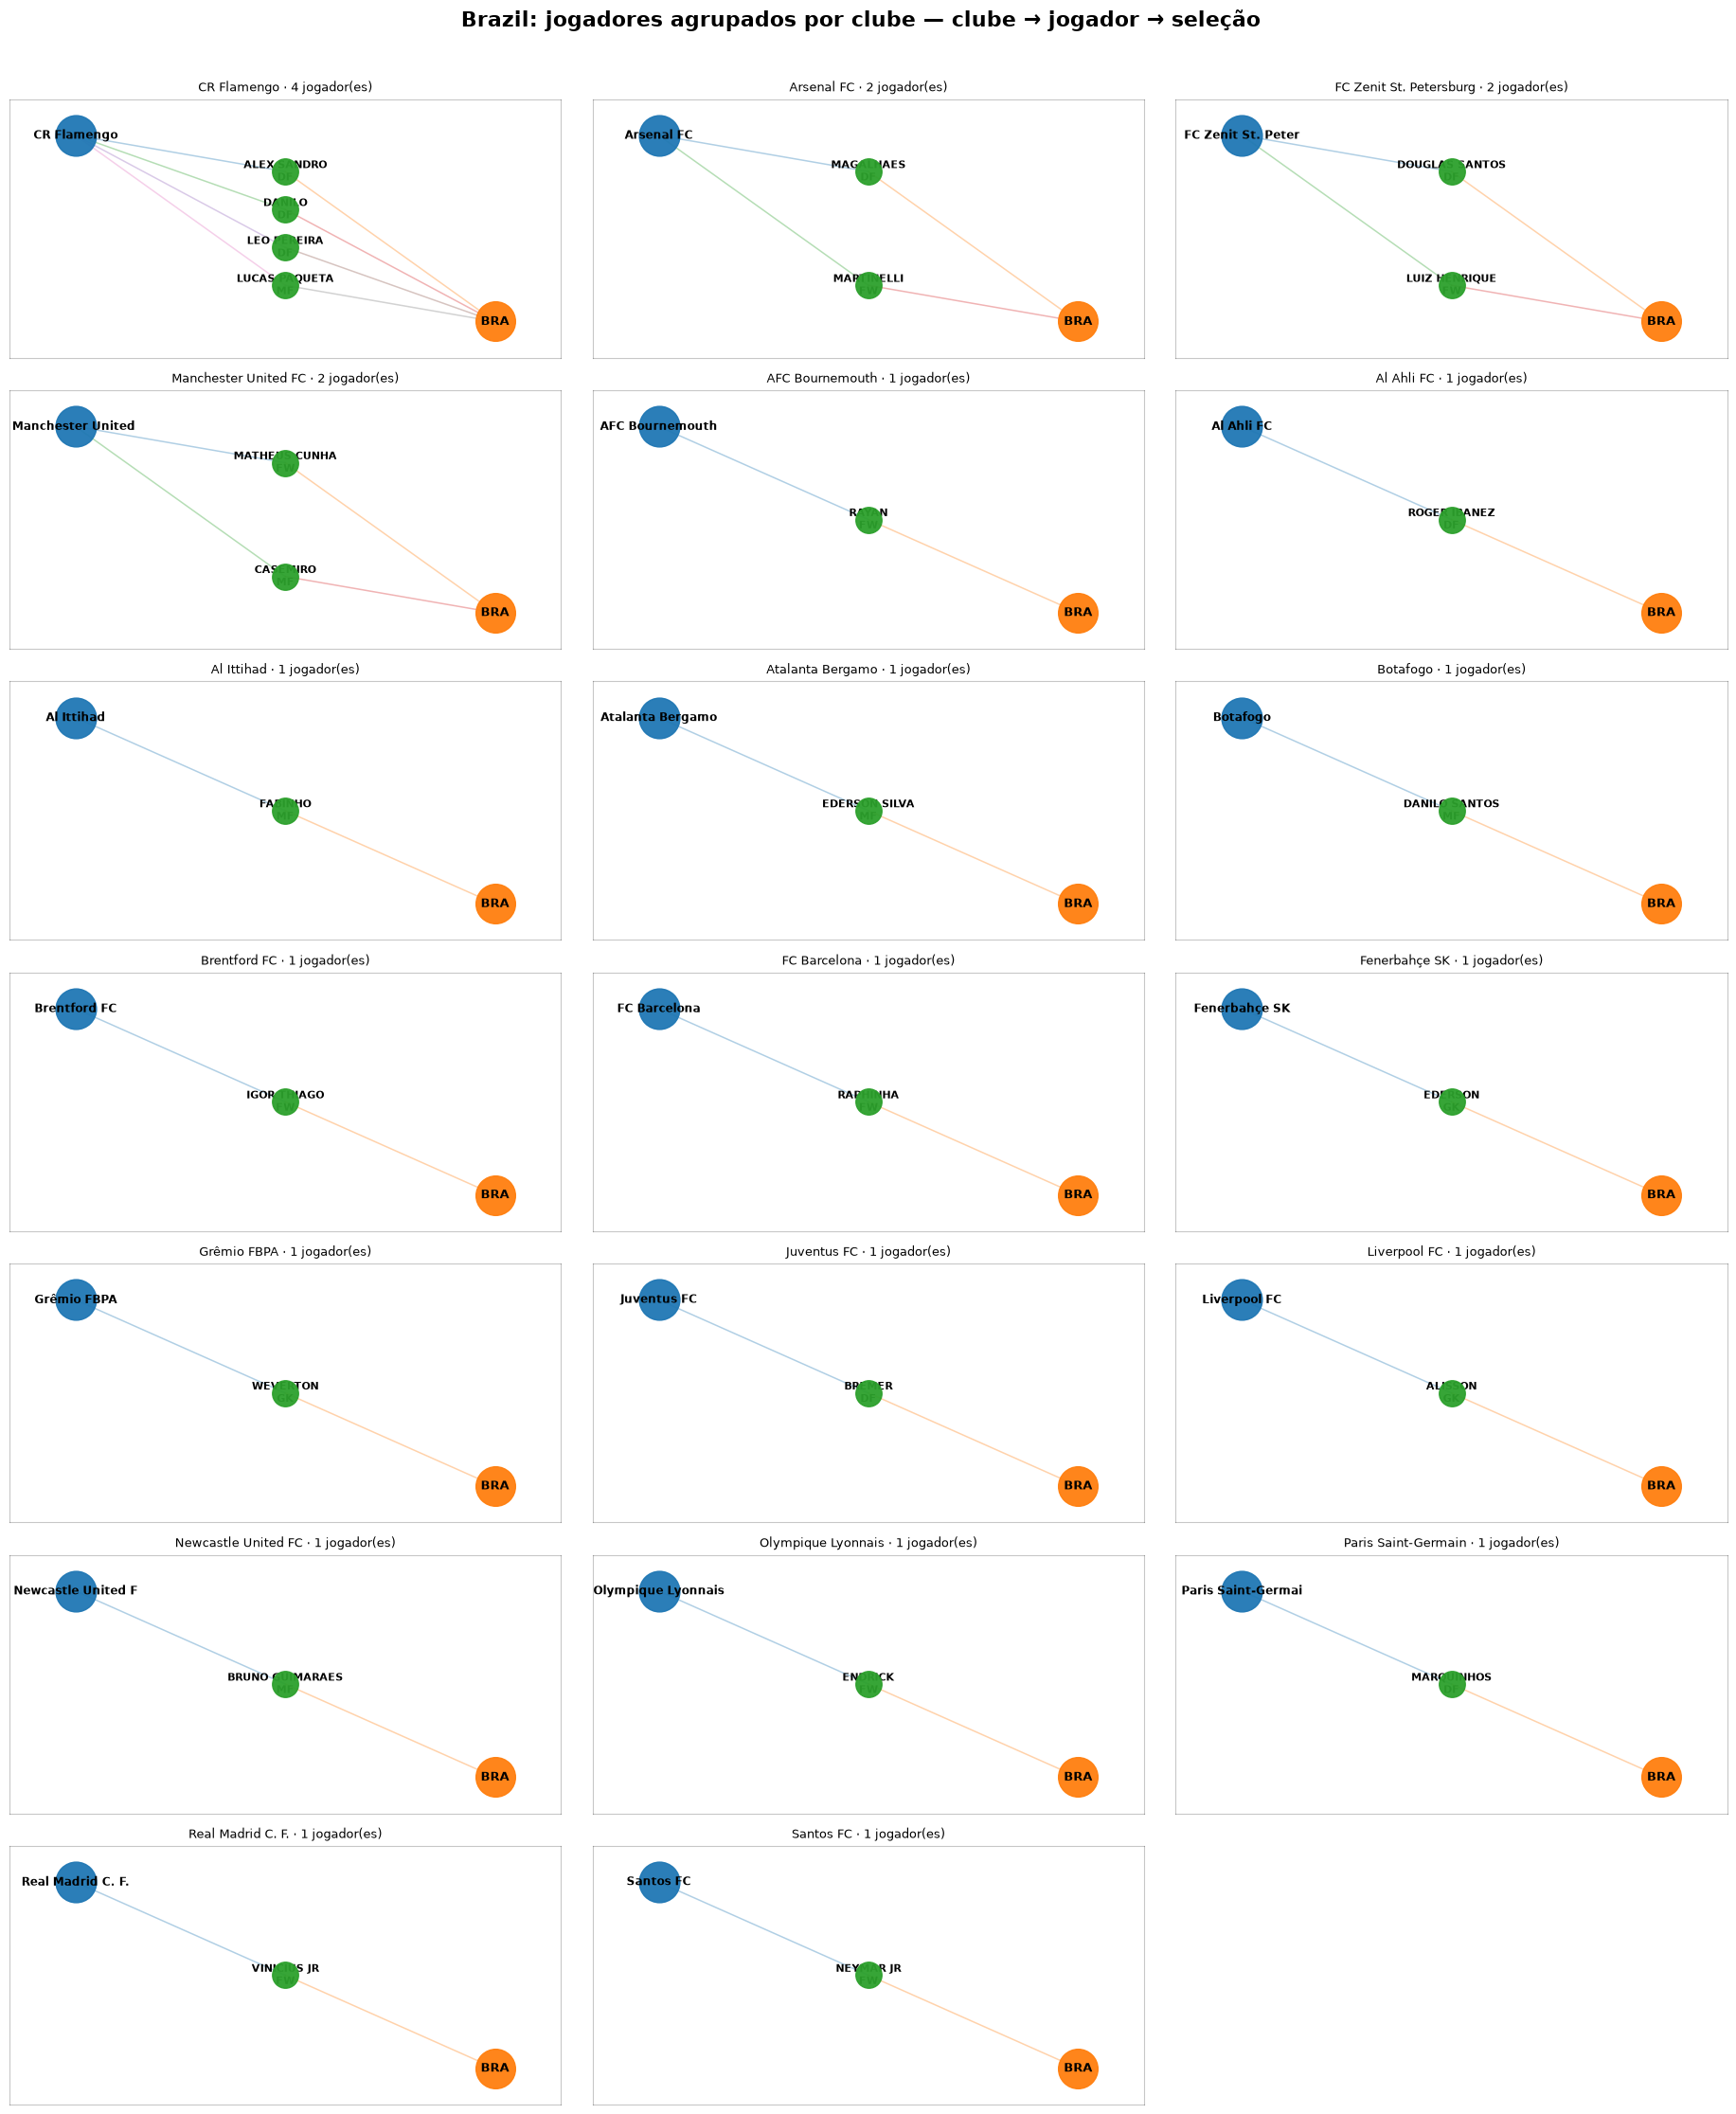

Plot salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/plots/brazil_roster_grouped_by_club.png


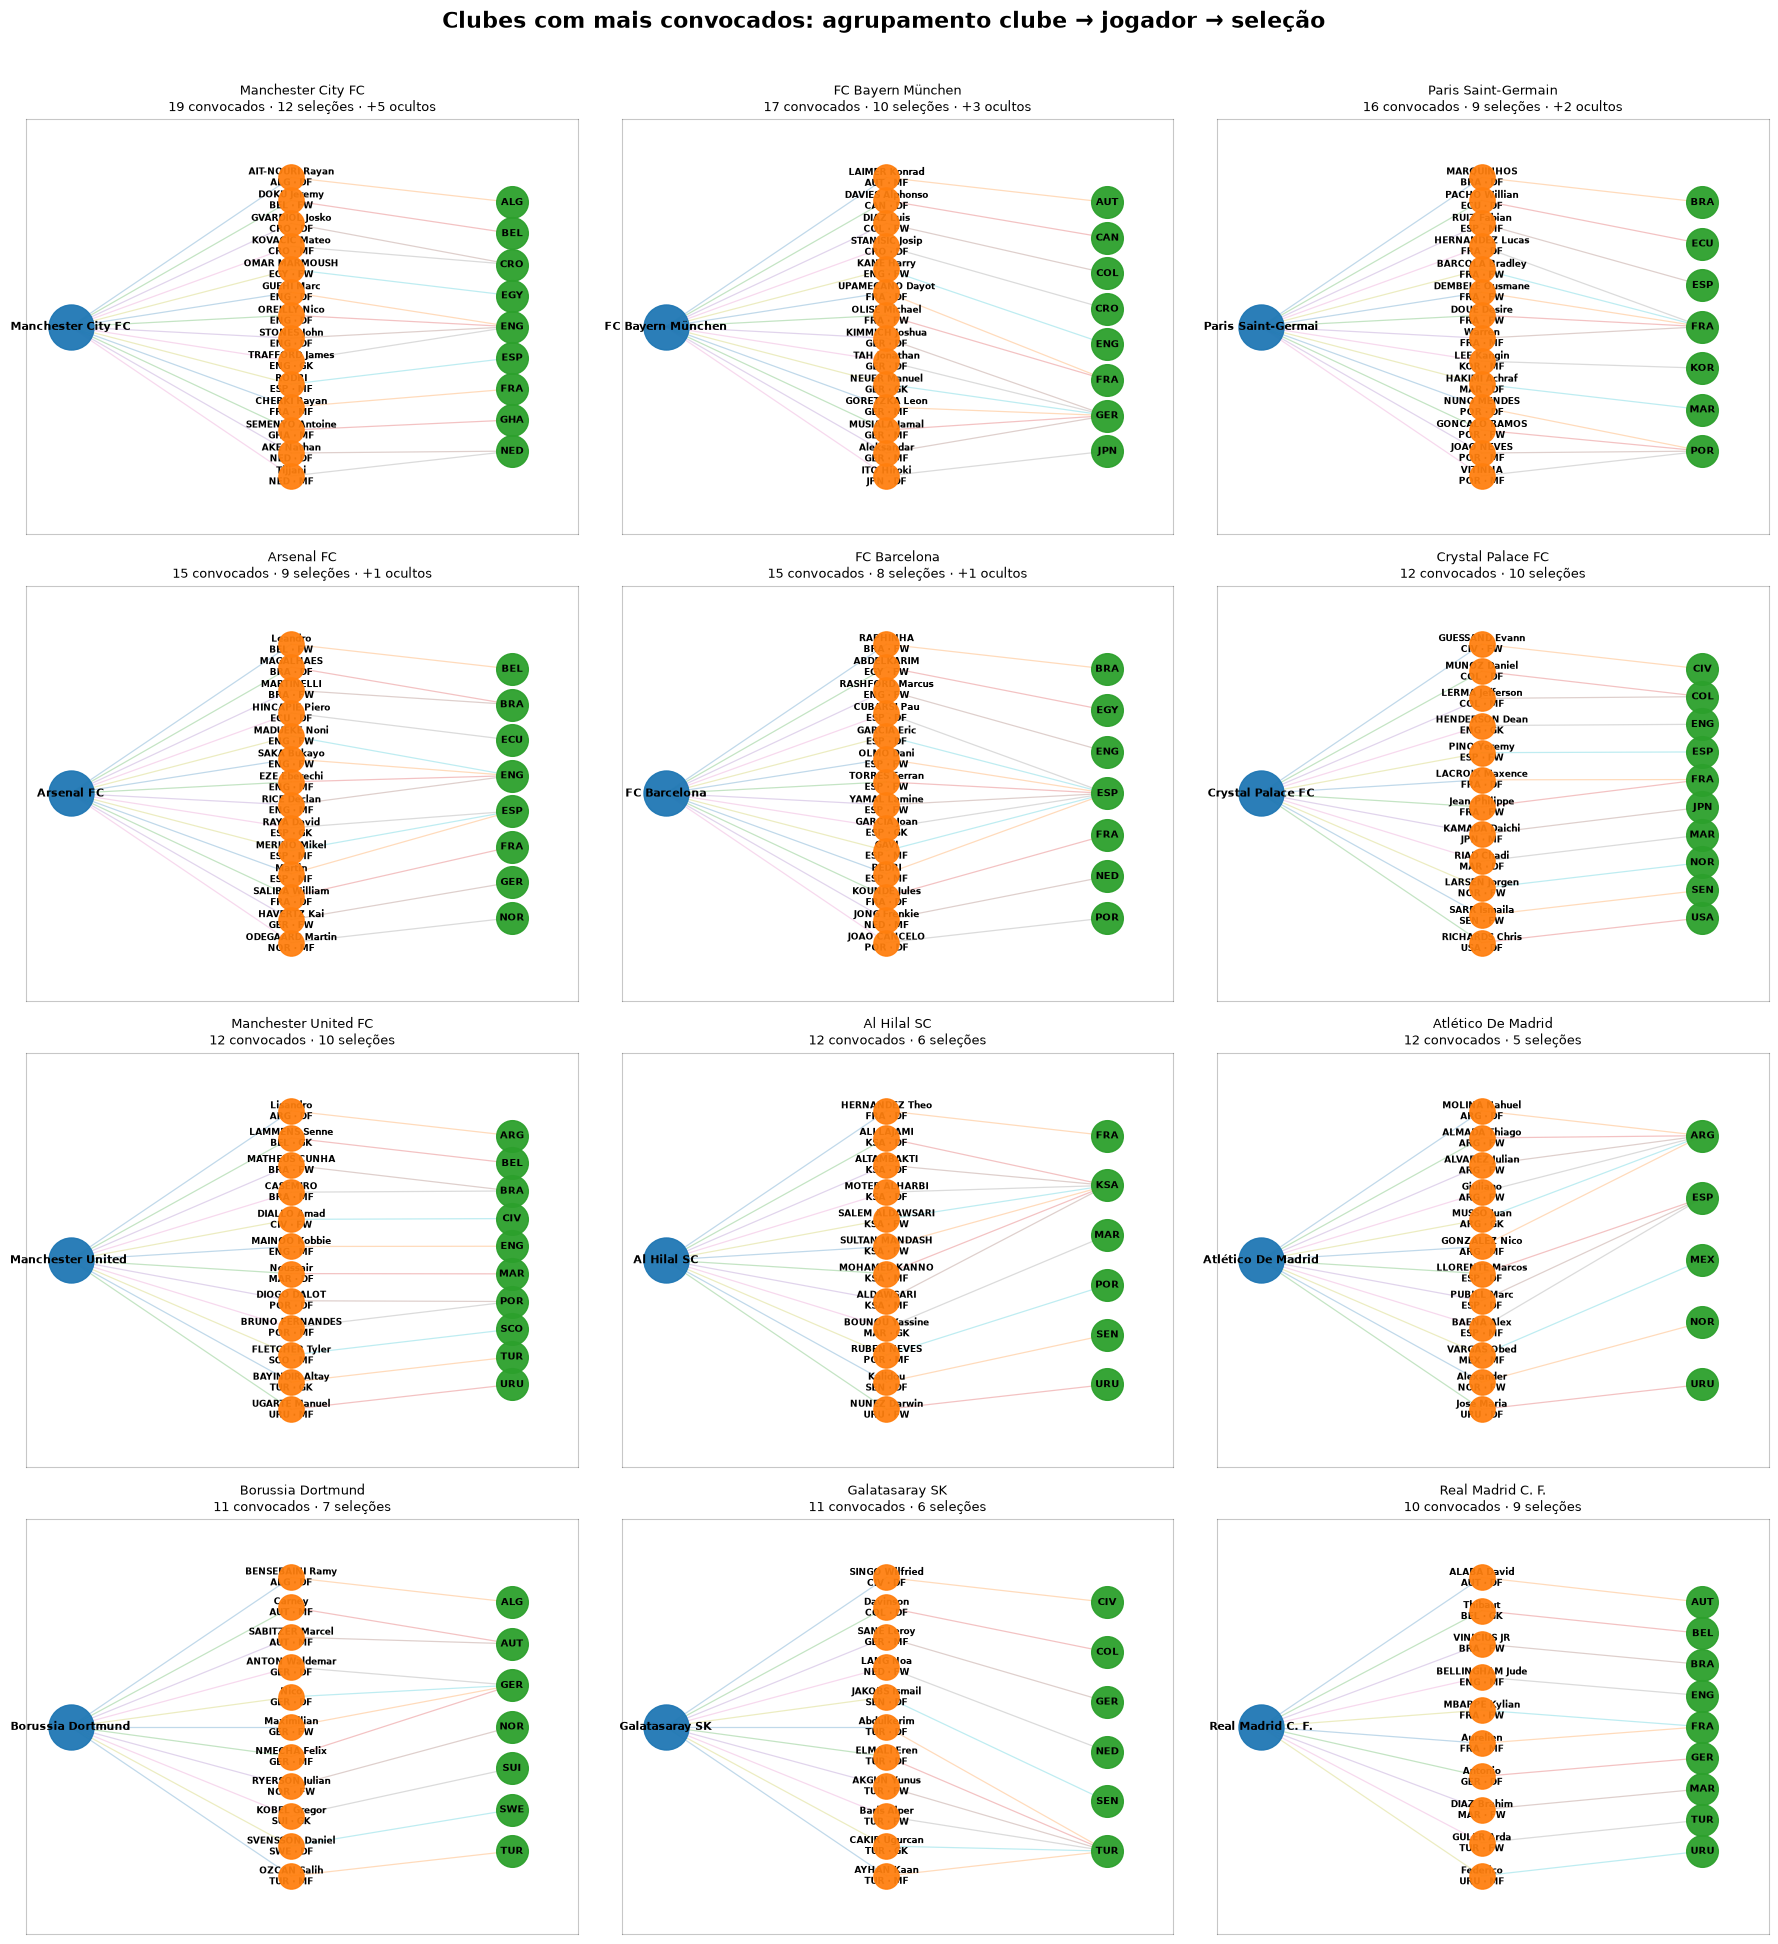

Plot salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/plots/top_clubs_grouped_player_team_affinity.png


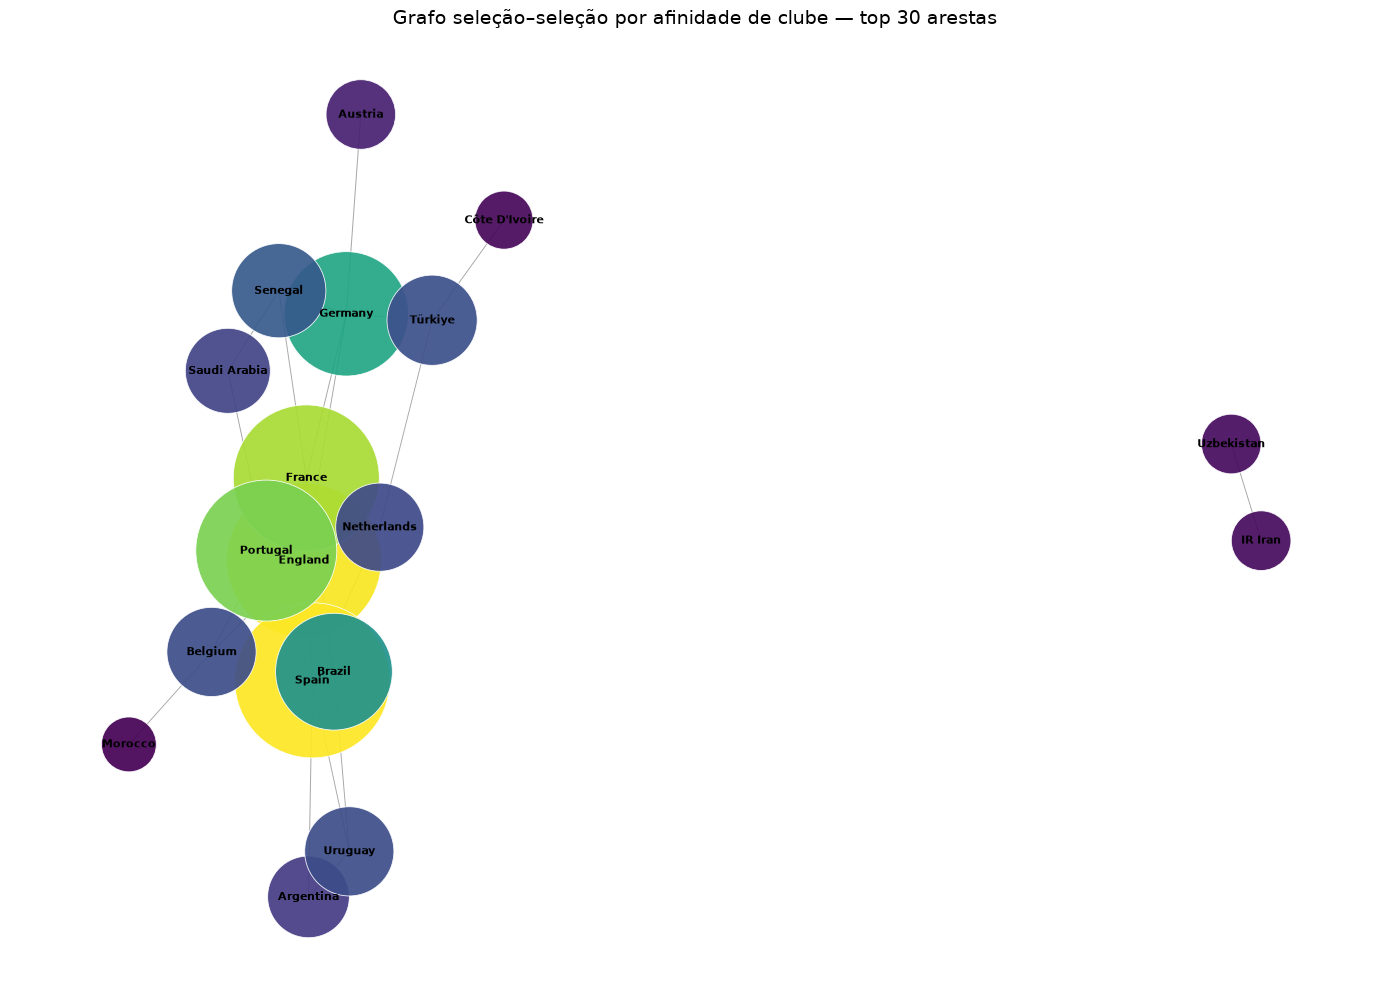

Plot salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/plots/team_same_club_affinity_network_top_edges_clean.png


,plot,path
0,brazil_roster_grouped_by_club,/home/perri/Área de trabalho/copa/copa_local_e...
1,top_clubs_grouped_player_team_affinity,/home/perri/Área de trabalho/copa/copa_local_e...
2,team_same_club_affinity_network_top_edges,/home/perri/Área de trabalho/copa/copa_local_e...


salvo: /home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/affinity_graph_plot_outputs.csv


PosixPath('/home/perri/Área de trabalho/copa/copa_local_etl_scripts/data/gold/eda_validada_outputs/affinity_graph_plot_outputs.csv')

In [14]:
PLOT_DIR = OUT_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)


def _short_name(name: str, max_len: int = 18) -> str:
    """Nome curto para rótulos de plot."""
    s = str(name).strip()
    if not s:
        return ""
    # No PDF da FIFA muitos nomes vêm como "SOBRENOME Nome"; para o plot, manter algo curto.
    parts = s.replace("JUNIOR", "JR").split()
    if len(parts) >= 2:
        # evita que todos os brasileiros fiquem só como sobrenome em caixa alta quando isso piora leitura
        s = " ".join(parts[-2:]) if len(" ".join(parts[-2:])) <= max_len else parts[-1]
    return s[:max_len]


def _club_label(club: str, max_len: int = 26) -> str:
    """Remove sufixo de país e encurta clube."""
    s = str(club).strip()
    s = re.sub(r"\s*\([A-Z]{3}\)\s*$", "", s)
    s = s.replace("Football Club", "FC").replace("Futbol Club", "FC")
    return s[:max_len]


def plot_selection_roster_grouped_by_club(players_df: pd.DataFrame, team: str = "Brazil", ncols: int = 4):
    """Plota uma seleção em cards por clube: clube -> jogadores -> seleção.

    É mais legível que spring_layout quando há muitos jogadores de uma mesma seleção.
    Troque team="Brazil" por team="Argentina", team="France" etc.
    """
    roster = players_df[
        players_df["team"].eq(team) | players_df["team_code"].eq(str(team).upper())
    ].copy()
    if roster.empty:
        print(f"Nenhum jogador encontrado para team={team!r}.")
        return None

    team_name = roster["team"].iloc[0]
    team_code = roster["team_code"].iloc[0]

    club_order = (
        roster.groupby("club", as_index=False)
        .agg(players=("player_name", "count"))
        .sort_values(["players", "club"], ascending=[False, True])
    )
    clubs = club_order["club"].tolist()

    n = len(clubs)
    ncols = min(max(1, ncols), n)
    nrows = int(math.ceil(n / ncols))

    fig_w = 6.2 * ncols
    fig_h = 3.15 * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axes_flat = axes.ravel()

    for ax, club in zip(axes_flat, clubs):
        g = roster[roster["club"].eq(club)].sort_values(["position", "player_name"]).reset_index(drop=True)
        m = len(g)

        # posições fixas dentro do card
        x_club = 0.12
        x_player = 0.50
        x_team = 0.88
        y_club = 0.86
        y_team = 0.14
        ys = np.linspace(0.72, 0.28, m) if m > 1 else np.array([0.50])

        # edges clube -> jogadores -> seleção
        for y in ys:
            ax.plot([x_club, x_player], [y_club, y], linewidth=1.1, alpha=0.35)
            ax.plot([x_player, x_team], [y, y_team], linewidth=1.1, alpha=0.35)

        # nós
        ax.scatter([x_club], [y_club], s=950, zorder=3, alpha=0.95)
        ax.scatter([x_team], [y_team], s=900, zorder=3, alpha=0.95)
        ax.scatter([x_player] * m, ys, s=390, zorder=4, alpha=0.95)

        # rótulos
        ax.text(x_club, y_club, _club_label(club, 18), ha="center", va="center", fontsize=8.5, fontweight="bold", wrap=True)
        ax.text(x_team, y_team, team_code, ha="center", va="center", fontsize=9.5, fontweight="bold")

        for y, (_, r) in zip(ys, g.iterrows()):
            label = f"{_short_name(r['player_name'], 16)}\n{r['position']}"
            ax.text(x_player, y, label, ha="center", va="center", fontsize=7.8, fontweight="bold")

        ax.set_title(f"{_club_label(club, 24)} · {m} jogador(es)", fontsize=9, pad=6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_alpha(0.22)

    for ax in axes_flat[len(clubs):]:
        ax.set_axis_off()

    fig.suptitle(
        f"{team_name}: jogadores agrupados por clube — clube → jogador → seleção",
        fontsize=16,
        fontweight="bold",
        y=1.01,
    )
    fig.tight_layout()

    safe_team = re.sub(r"[^A-Za-z0-9]+", "_", team_name).strip("_").lower()
    path = PLOT_DIR / f"{safe_team}_roster_grouped_by_club.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Plot salvo:", path)
    return path


def plot_top_clubs_grouped_player_team(players_df: pd.DataFrame, top_clubs: int = 12, ncols: int = 3, max_players_per_club: int = 14):
    """Plota os clubes com mais convocados em cards separados: clube -> jogadores -> seleções.

    Para clubes com muitos atletas, limita os rótulos a max_players_per_club para preservar legibilidade.
    """
    club_rank = (
        players_df.groupby("club", as_index=False)
        .agg(players=("player_name", "count"), teams=("team", "nunique"))
        .query("players >= 2")
        .sort_values(["players", "teams", "club"], ascending=[False, False, True])
        .head(top_clubs)
    )
    clubs = club_rank["club"].tolist()
    if not clubs:
        print("Nenhum clube com 2+ convocados.")
        return None

    n = len(clubs)
    ncols = min(max(1, ncols), n)
    nrows = int(math.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6.0 * ncols, 4.8 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, club in zip(axes_flat, clubs):
        g_all = players_df[players_df["club"].eq(club)].copy()
        g_all = g_all.sort_values(["team_code", "position", "player_name"]).reset_index(drop=True)
        g = g_all.head(max_players_per_club).copy()
        hidden = max(0, len(g_all) - len(g))

        teams = sorted(g["team_code"].dropna().unique().tolist())
        team_y = {t: y for t, y in zip(teams, np.linspace(0.80, 0.20, len(teams)) if len(teams) > 1 else [0.50])}
        player_y = np.linspace(0.86, 0.14, len(g)) if len(g) > 1 else np.array([0.50])

        x_club, x_player, x_team = 0.08, 0.48, 0.88
        y_club = 0.50

        for y, (_, r) in zip(player_y, g.iterrows()):
            ty = team_y.get(r["team_code"], 0.5)
            ax.plot([x_club, x_player], [y_club, y], linewidth=0.9, alpha=0.28)
            ax.plot([x_player, x_team], [y, ty], linewidth=0.9, alpha=0.28)

        ax.scatter([x_club], [y_club], s=1050, zorder=3, alpha=0.95)
        ax.text(x_club, y_club, _club_label(club, 18), ha="center", va="center", fontsize=8, fontweight="bold", wrap=True)

        ax.scatter([x_player] * len(g), player_y, s=330, zorder=4, alpha=0.94)
        for y, (_, r) in zip(player_y, g.iterrows()):
            label = f"{_short_name(r['player_name'], 15)}\n{r['team_code']} · {r['position']}"
            ax.text(x_player, y, label, ha="center", va="center", fontsize=6.4, fontweight="bold")

        ax.scatter([x_team] * len(teams), [team_y[t] for t in teams], s=520, zorder=3, alpha=0.95)
        for t in teams:
            ax.text(x_team, team_y[t], t, ha="center", va="center", fontsize=7.5, fontweight="bold")

        subtitle = f"{len(g_all)} convocados · {g_all['team'].nunique()} seleções"
        if hidden:
            subtitle += f" · +{hidden} ocultos"
        ax.set_title(f"{_club_label(club, 28)}\n{subtitle}", fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_alpha(0.22)

    for ax in axes_flat[len(clubs):]:
        ax.set_axis_off()

    fig.suptitle(
        f"Clubes com mais convocados: agrupamento clube → jogador → seleção",
        fontsize=16,
        fontweight="bold",
        y=1.01,
    )
    fig.tight_layout()

    path = PLOT_DIR / "top_clubs_grouped_player_team_affinity.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Plot salvo:", path)
    return path


def plot_team_affinity_network(between_affinity: pd.DataFrame, top_edges: int = 30):
    """Plot seleção-seleção mais limpo, com menos arestas."""
    if between_affinity.empty:
        print("Sem afinidade entre seleções para plotar.")
        return None

    df = between_affinity.copy()
    df["plot_score"] = df["affinity_density"].fillna(0) * np.log1p(df["edges_count"])
    df = df.sort_values(["plot_score", "edges_count", "affinity_density"], ascending=[False, False, False]).head(top_edges)

    T = nx.Graph()
    for _, r in df.iterrows():
        T.add_edge(
            r["team_a"],
            r["team_b"],
            weight=float(r["edges_count"]),
            density=float(r["affinity_density"]),
            clubs_shared=int(r["clubs_shared"]),
            sample_clubs=str(r["sample_clubs"]),
        )

    if T.number_of_nodes() == 0:
        print("Grafo seleção-seleção vazio.")
        return None

    pos = nx.spring_layout(T, seed=7, k=1.35, iterations=220, weight="weight")
    weighted_degree = dict(T.degree(weight="weight"))
    max_density = max([T.edges[e].get("density", 0.0) for e in T.edges] + [1.0])
    node_sizes = [420 + 95 * weighted_degree[n] for n in T.nodes]
    edge_widths = [0.6 + 4.0 * T.edges[e].get("density", 0.0) / max_density for e in T.edges]

    fig, ax = plt.subplots(figsize=(14, 10))
    nx.draw_networkx_edges(T, pos, ax=ax, width=edge_widths, alpha=0.34)
    nx.draw_networkx_nodes(
        T,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=list(weighted_degree.values()),
        cmap=plt.cm.viridis,
        alpha=0.92,
        linewidths=0.6,
        edgecolors="white",
    )
    nx.draw_networkx_labels(T, pos, ax=ax, font_size=8, font_weight="bold")

    ax.set_title(f"Grafo seleção–seleção por afinidade de clube — top {len(df)} arestas", fontsize=14)
    ax.set_axis_off()
    fig.tight_layout()

    path = PLOT_DIR / "team_same_club_affinity_network_top_edges_clean.png"
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Plot salvo:", path)
    return path


# Plot principal solicitado: seleção agrupada por clubes.
selection_graph_png = plot_selection_roster_grouped_by_club(players, team="Brazil", ncols=3)

# Plot complementar: clubes com mais convocados, também separado em cards.
grouped_club_graph_png = plot_top_clubs_grouped_player_team(players, top_clubs=12, ncols=3, max_players_per_club=14)

# Mantém o plot seleção-seleção, mas com menos arestas para reduzir poluição visual.
team_graph_png = plot_team_affinity_network(between_affinity, top_edges=30)

plot_outputs = pd.DataFrame([
    {"plot": "brazil_roster_grouped_by_club", "path": str(selection_graph_png) if selection_graph_png else "não gerado"},
    {"plot": "top_clubs_grouped_player_team_affinity", "path": str(grouped_club_graph_png) if grouped_club_graph_png else "não gerado"},
    {"plot": "team_same_club_affinity_network_top_edges", "path": str(team_graph_png) if team_graph_png else "não gerado"},
])
display(plot_outputs)
save_df(plot_outputs, "affinity_graph_plot_outputs.csv")


## 10. Resumo final e limitações

Conclusões permitidas:

- Descrever distribuição de idade, altura, caps, gols, clubes e posição a partir da Squad List oficial da FIFA.
- Medir concentração de jogadores por clube e por país do clube.
- Medir afinidade por **mesmo clube**, separando coesão interna e conexão entre seleções.
- Descrever gols/partidas apenas quando houver base local de placares e sem double counting.

Conclusões **não** permitidas sem dados adicionais:

- Dizer que afinidade por clube prova entrosamento real.
- Dizer que uma seleção é melhor apenas por ter mais caps ou mais gols acumulados.
- Fazer causalidade sobre média de gols sem força dos adversários, xG, Elo/ranking, odds pré-jogo e validação out-of-sample.

In [ ]:
summary = {
    "players_source": "FIFA SquadLists-English.pdf",
    "players_total": int(len(players)),
    "teams_total": int(players["team_code"].nunique()),
    "players_per_team_ok": bool((players.groupby("team_code").size() == 26).all()),
    "clubs_total": int(players["club"].nunique()),
    "club_countries_total": int(players["club_country_code"].nunique()),
    "same_club_edges": int(len(edges)),
    "graph_nodes": int(G.number_of_nodes()),
    "graph_edges": int(G.number_of_edges()),
    "output_dir": str(OUT_DIR),
    "method_note": "FIFA oficial vence conflitos em height/caps/goals; liga não é inferida; partidas são opcionais e deduplicadas por fixture.",
}

summary_path = OUT_DIR / "eda_validada_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(summary, ensure_ascii=False, indent=2))
print("\nArquivos gerados:")
for p in sorted(OUT_DIR.glob("*")):
    print("-", p.name)